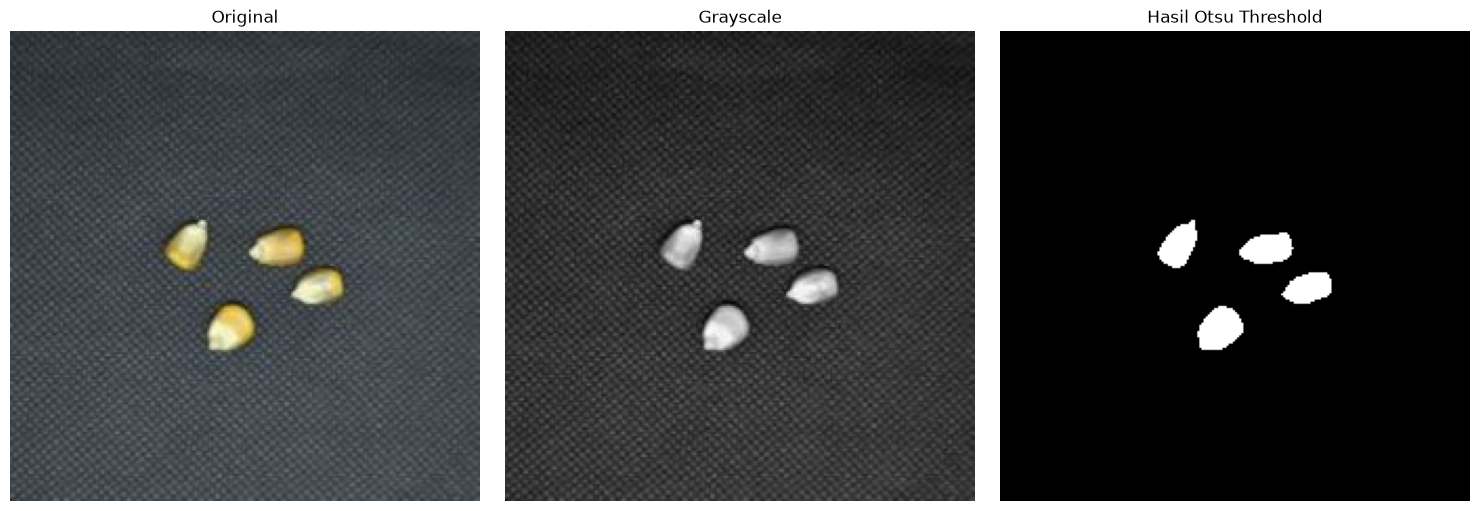

In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "../data/raw/sehat/normal_002.JPG"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1: ubah ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2: mengurangi noise dengan Gaussian Blur sebelum thresholding
# (5,5) = ukuran kernel blur, 0 = standar deviasi dihitung otomatis oleh OpenCV
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 3: Otsu thresholding
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# hasil
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[1].imshow(gray, cmap='gray')
axes[1].set_title("Grayscale")
axes[2].imshow(thresh, cmap='gray')
axes[2].set_title("Hasil Otsu Threshold")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

Jumlah kontur terdeteksi: 5
Jumlah biji valid (setelah filter noise): 5


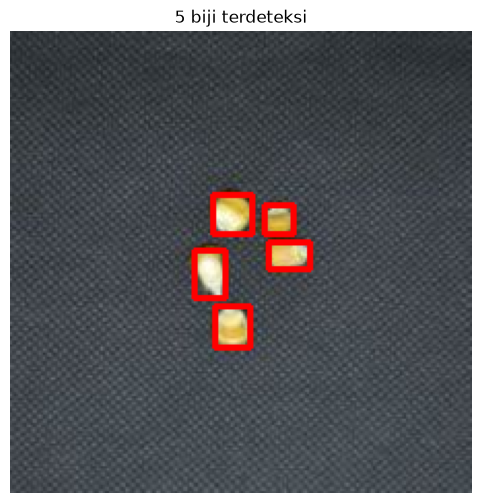

In [52]:
# 4: mencari kontur (garis tepi) dari tiap blob putih di hasil threshold
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Jumlah kontur terdeteksi: {len(contours)}")

# 5: memfilter kontur yang terlalu kecil
MIN_AREA = 100  # ambang batas minimal luas piksel
biji_contours = [c for c in contours if cv2.contourArea(c) > MIN_AREA]

print(f"Jumlah biji valid (setelah filter noise): {len(biji_contours)}")

# 6: menggambar bounding box (kotak pembatas) di sekitar tiap biji untuk verifikasi visual
img_with_boxes = img_rgb.copy()
for c in biji_contours:
    x, y, w, h = cv2.boundingRect(c)  # (x,y) = pojok kiri-atas kotak, w,h = lebar & tinggi kotak
    cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (255, 0, 0), 2)  # kotak merah, tebal 2px

plt.figure(figsize=(6, 6))
plt.imshow(img_with_boxes)
plt.title(f"{len(biji_contours)} biji terdeteksi")
plt.axis('off')
plt.show()

In [53]:
# Diagnosis: menampilkan luas semua kontur SEBELUM difilter, urut dari kecil ke besar
semua_area = sorted([cv2.contourArea(c) for c in contours])
print("Luas semua kontur terdeteksi (piksel):")
print(semua_area)

Luas semua kontur terdeteksi (piksel):
[127.5, 190.0, 220.0, 233.0, 243.0]


In [54]:
import numpy as np
import cv2
import os
import pandas as pd

# membuat folder untuk menyimpan hasil crop
os.makedirs("../data/cropped/sehat", exist_ok=True)
os.makedirs("../data/cropped/terkontaminasi", exist_ok=True)

MIN_AREA = 100
MARGIN = 3

def deteksi_dan_crop(img_path, label, folder_tujuan, sumber_nama):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological Opening: memutus jembatan tipis & buang noise kecil,
    # sambil pertahankan ukuran objek yang selamat mendekati aslinya
    kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_morph, iterations=2)

    contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter DUA arah: buang yang terlalu kecil (noise) DAN yang terlalu besar
    # (artefak background atau tumpukan banyak biji menyatu)
    MIN_AREA = 100
    MAX_AREA = 700  # berdasarkan biji valid terbesar yang pernah kita lihat (~547px), + margin
    biji_contours = [c for c in contours if MIN_AREA < cv2.contourArea(c) < MAX_AREA]

    hasil = []
    h_img, w_img = img.shape[:2]

    for idx, c in enumerate(biji_contours):
        x, y, w, h = cv2.boundingRect(c)
        x1 = max(x - MARGIN, 0)
        y1 = max(y - MARGIN, 0)
        x2 = min(x + w + MARGIN, w_img)
        y2 = min(y + h + MARGIN, h_img)

        crop = img[y1:y2, x1:x2]

        nama_file_crop = f"{sumber_nama}_biji{idx+1}.jpg"
        path_simpan = os.path.join(folder_tujuan, nama_file_crop)
        cv2.imwrite(path_simpan, crop)

        hasil.append({
            "filename": nama_file_crop,
            "source_file": sumber_nama,
            "label": label,
            "area_piksel": cv2.contourArea(c),
            "width": x2 - x1,
            "height": y2 - y1
        })

    return hasil

manifest = []

for label, path_folder, folder_tujuan in [
    ("sehat", "../data/raw/sehat", "../data/cropped/sehat"),
    ("terkontaminasi", "../data/raw/terkontaminasi", "../data/cropped/terkontaminasi"),
]:
    daftar_file = os.listdir(path_folder)
    for nama_file in daftar_file:
        img_path = os.path.join(path_folder, nama_file)
        sumber_nama = os.path.splitext(nama_file)[0]
        hasil_crop = deteksi_dan_crop(img_path, label, folder_tujuan, sumber_nama)
        manifest.extend(hasil_crop)

df_manifest = pd.DataFrame(manifest)
df_manifest.to_csv("../data/manifest_crop.csv", index=False)

print(f"Total crop dihasilkan: {len(df_manifest)}")
print(df_manifest["label"].value_counts())
print("\nStatistik luas piksel per crop:")
print(df_manifest["area_piksel"].describe())

Total crop dihasilkan: 238
label
sehat             149
terkontaminasi     89
Name: count, dtype: int64

Statistik luas piksel per crop:
count    238.000000
mean     323.239496
std      163.444843
min      101.500000
25%      192.625000
50%      259.750000
75%      453.875000
max      693.500000
Name: area_piksel, dtype: float64


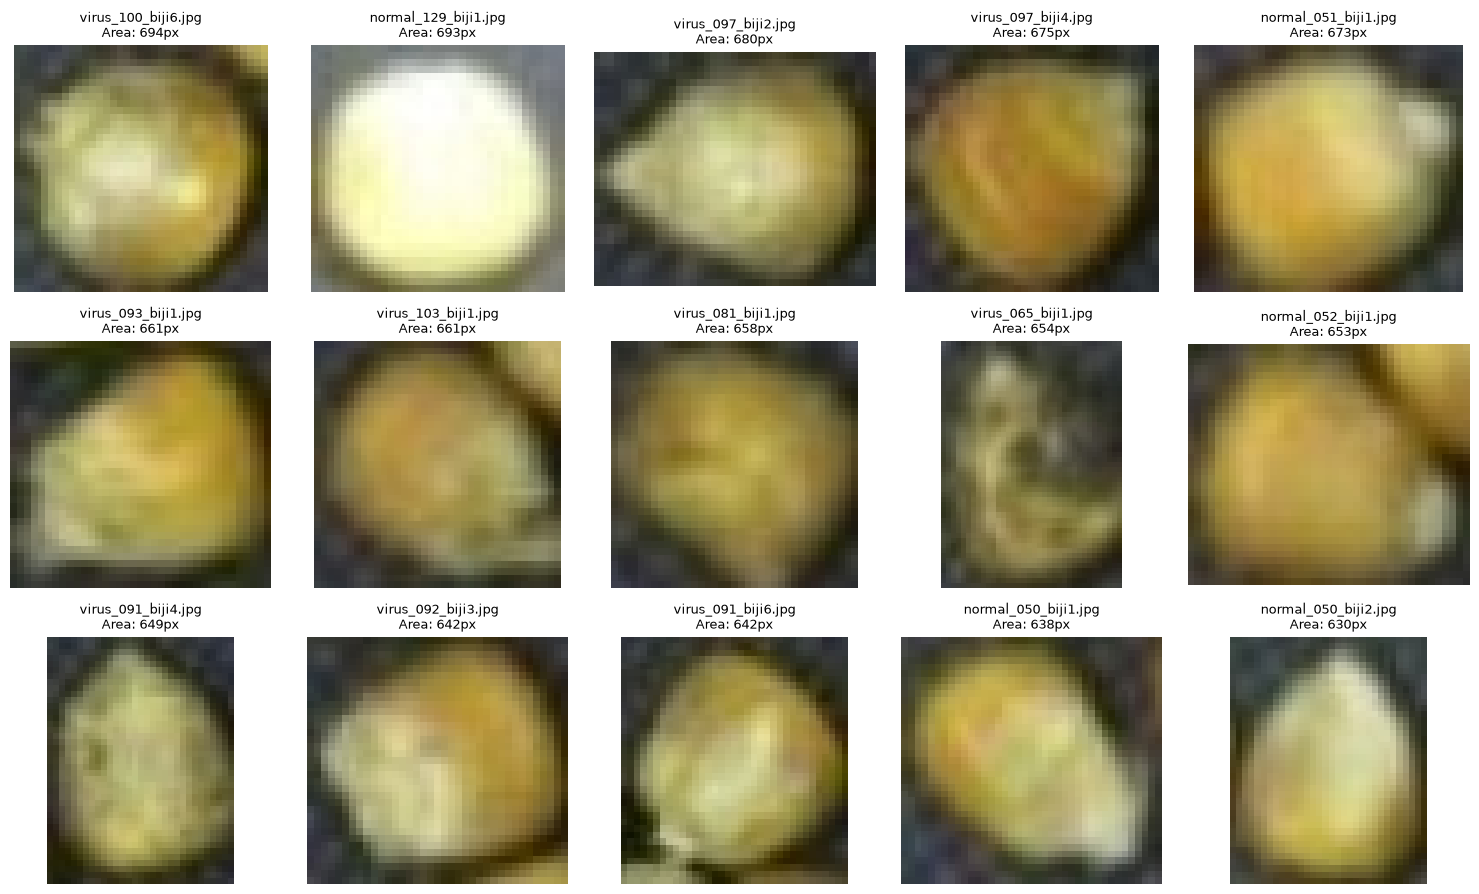

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os

# mengurutkan manifest berdasarkan luas piksel, dari yang terbesar
df_sorted = df_manifest.sort_values("area_piksel", ascending=False)

top_n = 15
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(top_n):
    row = df_sorted.iloc[i]
    folder = "../data/cropped/sehat" if row["label"] == "sehat" else "../data/cropped/terkontaminasi"
    img_path = os.path.join(folder, row["filename"])
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{row['filename']}\nArea: {row['area_piksel']:.0f}px", fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [56]:
# menghitung rasio isi kotak
df_manifest["fill_ratio"] = df_manifest["area_piksel"] / (df_manifest["width"] * df_manifest["height"])

# mengurutkan dari rasio terkecil
df_sorted_fill = df_manifest.sort_values("fill_ratio", ascending=True)

print("10 crop dengan fill_ratio terendah (kandidat noise/crease):")
print(df_sorted_fill[["filename", "area_piksel", "width", "height", "fill_ratio"]].head(10))

print("\nStatistik fill_ratio keseluruhan:")
print(df_manifest["fill_ratio"].describe())

10 crop dengan fill_ratio terendah (kandidat noise/crease):
                  filename  area_piksel  width  height  fill_ratio
172    virus_091_biji3.jpg        177.0     30      23    0.256522
209    virus_105_biji6.jpg        105.0     19      21    0.263158
36    normal_026_biji2.jpg        101.5     18      21    0.268519
189    virus_100_biji2.jpg        102.5     20      18    0.284722
186    virus_098_biji1.jpg        133.5     21      22    0.288961
153    virus_051_biji4.jpg        116.0     21      19    0.290727
89    normal_039_biji5.jpg        149.5     19      26    0.302632
83    normal_038_biji4.jpg        110.0     19      19    0.304709
82    normal_038_biji3.jpg        122.0     20      20    0.305000
129  normal_045_biji10.jpg        477.5     41      38    0.306483

Statistik fill_ratio keseluruhan:
count    238.000000
mean       0.398023
std        0.055049
min        0.256522
25%        0.359063
50%        0.391806
75%        0.440151
max        0.550000
Name: fi

In [57]:
# Aspect ratio = sisi terpanjang dibagi sisi terpendek dari bounding box
# Nilai mendekati 1 = kotak proporsional (persegi/oval wajar)
# Nilai tinggi (misal >3) = kotak memanjang ke satu arah
df_manifest["aspect_ratio"] = (
    df_manifest[["width", "height"]].max(axis=1) / df_manifest[["width", "height"]].min(axis=1)
)

df_besar = df_manifest[df_manifest["area_piksel"] > 3000].sort_values("area_piksel", ascending=False)
print(df_besar[["filename", "area_piksel", "width", "height", "aspect_ratio", "fill_ratio"]].to_string())

Empty DataFrame
Columns: [filename, area_piksel, width, height, aspect_ratio, fill_ratio]
Index: []


In [58]:
# menghitung berapa biji terdeteksi per foto sumber (source_file)
jumlah_per_foto = df_manifest.groupby("source_file").size().sort_values(ascending=False)

print("Distribusi jumlah biji per foto sumber:")
print(jumlah_per_foto.describe())

print("\nFoto dengan biji terbanyak (kandidat 'tumpukan'):")
print(jumlah_per_foto.head(10))

tumpukan = jumlah_per_foto[jumlah_per_foto > 5]
print(f"\nJumlah foto kandidat 'tumpukan' (>5 biji terdeteksi): {len(tumpukan)}")
print(f"Total biji dari foto-foto tumpukan ini: {tumpukan.sum()}")

Distribusi jumlah biji per foto sumber:
count    77.000000
mean      3.090909
std       3.061569
min       1.000000
25%       1.000000
50%       1.000000
75%       4.000000
max      15.000000
dtype: float64

Foto dengan biji terbanyak (kandidat 'tumpukan'):
source_file
normal_034    15
normal_045    12
virus_108     11
normal_044     9
virus_100      9
virus_109      9
normal_036     8
normal_041     7
virus_091      7
normal_039     7
dtype: int64

Jumlah foto kandidat 'tumpukan' (>5 biji terdeteksi): 15
Total biji dari foto-foto tumpukan ini: 125


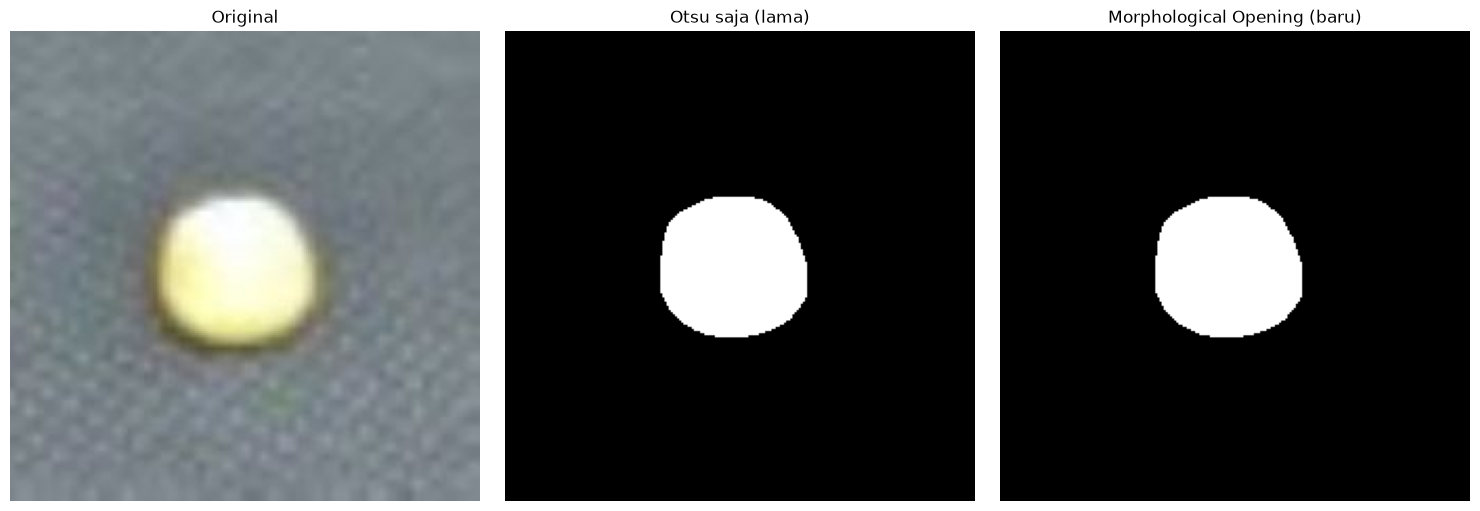

Jumlah kontur: 1
Luas tiap kontur: [3775.0]


In [68]:
# Uji coba pada 1 foto yang masih bermasalah
img_path_test = "../data/raw/sehat/normal_031.JPG"
img_test = cv2.imread(img_path_test)
img_test_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
gray_test = cv2.cvtColor(img_test, cv2.COLOR_BGR2GRAY)
blur_test = cv2.GaussianBlur(gray_test, (5, 5), 0)
_, thresh_test = cv2.threshold(blur_test, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Structuring element bentuk elips (lebih halus dari persegi untuk objek bulat/oval seperti biji)
kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# MORPH_OPEN = erode lalu dilate dengan kernel yang sama
# Erode memutus jembatan tipis, dilate mengembalikan ukuran objek yang selamat mendekati semula
opened_test = cv2.morphologyEx(thresh_test, cv2.MORPH_OPEN, kernel_morph, iterations=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_test_rgb)
axes[0].set_title("Original")
axes[1].imshow(thresh_test, cmap='gray')
axes[1].set_title("Otsu saja (lama)")
axes[2].imshow(opened_test, cmap='gray')
axes[2].set_title("Morphological Opening (baru)")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Cek jumlah & luas kontur hasil metode baru
contours_test, _ = cv2.findContours(opened_test, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
luas_test = sorted([cv2.contourArea(c) for c in contours_test])
print(f"Jumlah kontur: {len(contours_test)}")
print(f"Luas tiap kontur: {luas_test}")

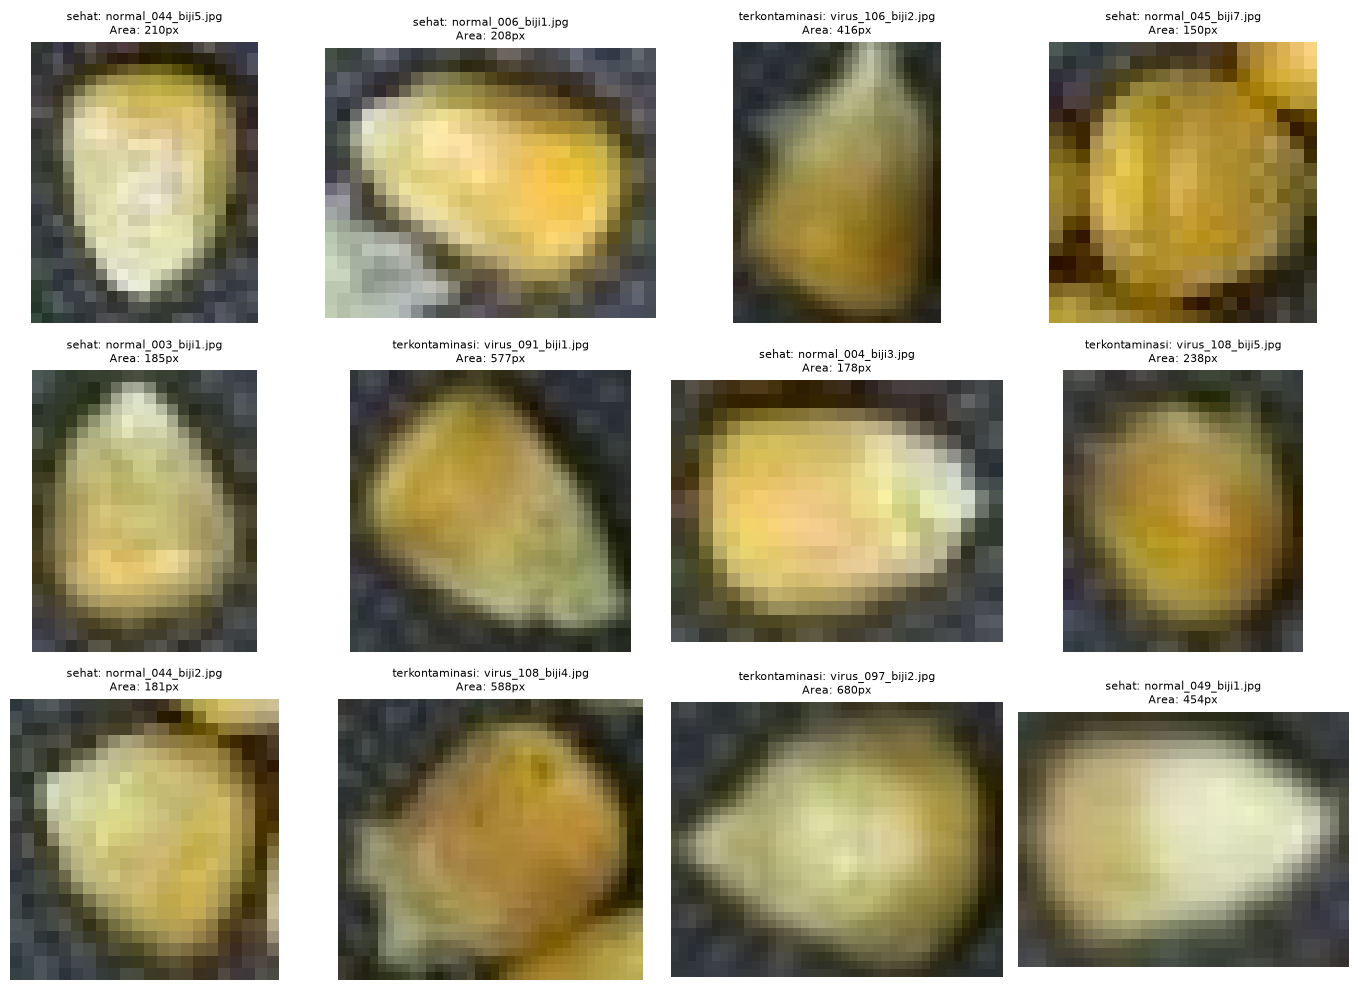

In [60]:
import random

# Ambil 12 sampel ACAK dari seluruh 105 crop (bukan diurutkan), campur kedua label
random.seed(42)  # supaya hasilnya konsisten kalau dijalankan ulang, bukan acak berbeda tiap kali
sampel_acak = df_manifest.sample(n=12, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(sampel_acak.iterrows()):
    folder = "../data/cropped/sehat" if row["label"] == "sehat" else "../data/cropped/terkontaminasi"
    img_path = os.path.join(folder, row["filename"])
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{row['label']}: {row['filename']}\nArea: {row['area_piksel']:.0f}px", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [61]:
import os
import pandas as pd

df_manifest = pd.read_csv("../data/manifest_crop.csv")

semua_foto = set()
for label, folder in [("sehat", "../data/raw/sehat"), ("terkontaminasi", "../data/raw/terkontaminasi")]:
    for nama_file in os.listdir(folder):
        semua_foto.add(os.path.splitext(nama_file)[0])  # nama tanpa ekstensi

foto_ada_crop = set(df_manifest["source_file"].unique())
foto_tanpa_crop = semua_foto - foto_ada_crop

print(f"Total foto: {len(semua_foto)}")
print(f"Foto tanpa crop sama sekali: {len(foto_tanpa_crop)}")
print(sorted(foto_tanpa_crop))

Total foto: 238
Foto tanpa crop sama sekali: 161
['normal_031', 'normal_032', 'normal_054', 'normal_055', 'normal_056', 'normal_057', 'normal_058', 'normal_059', 'normal_060', 'normal_061', 'normal_062', 'normal_063', 'normal_064', 'normal_065', 'normal_066', 'normal_067', 'normal_068', 'normal_069', 'normal_070', 'normal_071', 'normal_072', 'normal_073', 'normal_074', 'normal_075', 'normal_076', 'normal_077', 'normal_078', 'normal_080', 'normal_081', 'normal_082', 'normal_083', 'normal_084', 'normal_085', 'normal_086', 'normal_087', 'normal_088', 'normal_089', 'normal_090', 'normal_091', 'normal_092', 'normal_093', 'normal_094', 'normal_095', 'normal_096', 'normal_097', 'normal_098', 'normal_099', 'normal_100', 'normal_101', 'normal_102', 'normal_103', 'normal_104', 'normal_105', 'normal_106', 'normal_107', 'normal_108', 'normal_109', 'normal_110', 'normal_111', 'normal_112', 'normal_113', 'normal_114', 'normal_115', 'normal_116', 'normal_117', 'normal_118', 'normal_119', 'normal_120'

In [62]:
import pandas as pd

# baca ulang manifest langsung dari file, supaya tidak tergantung
# apakah df_manifest di memori sudah punya kolom tambahan atau belum
df_manifest = pd.read_csv("../data/manifest_crop.csv")

# hitung ulang fill_ratio di sini juga (rasio luas biji terhadap luas kotak bounding box)
df_manifest["fill_ratio"] = df_manifest["area_piksel"] / (df_manifest["width"] * df_manifest["height"])

# gabungkan dua indikator: fill_ratio rendah ATAU area mendekati MAX_AREA (700)
kandidat_noise = df_manifest[
    (df_manifest["fill_ratio"] < 0.30) | (df_manifest["area_piksel"] > 550)
].sort_values("area_piksel", ascending=False)

print(f"Jumlah kandidat perlu dicek manual: {len(kandidat_noise)}")
print(kandidat_noise[["filename", "source_file", "label", "area_piksel", "fill_ratio"]])

Jumlah kandidat perlu dicek manual: 36
                 filename source_file           label  area_piksel  fill_ratio
193   virus_100_biji6.jpg   virus_100  terkontaminasi        693.5    0.520646
148  normal_129_biji1.jpg  normal_129           sehat        693.0    0.550000
183   virus_097_biji2.jpg   virus_097  terkontaminasi        680.5    0.488164
185   virus_097_biji4.jpg   virus_097  terkontaminasi        675.0    0.506757
142  normal_051_biji1.jpg  normal_051           sehat        673.0    0.506015
199   virus_103_biji1.jpg   virus_103  terkontaminasi        661.0    0.482834
180   virus_093_biji1.jpg   virus_093  terkontaminasi        661.0    0.510425
161   virus_081_biji1.jpg   virus_081  terkontaminasi        657.5    0.480278
159   virus_065_biji1.jpg   virus_065  terkontaminasi        654.0    0.370748
143  normal_052_biji1.jpg  normal_052           sehat        653.0    0.455052
173   virus_091_biji4.jpg   virus_091  terkontaminasi        649.0    0.510622
179   virus_0

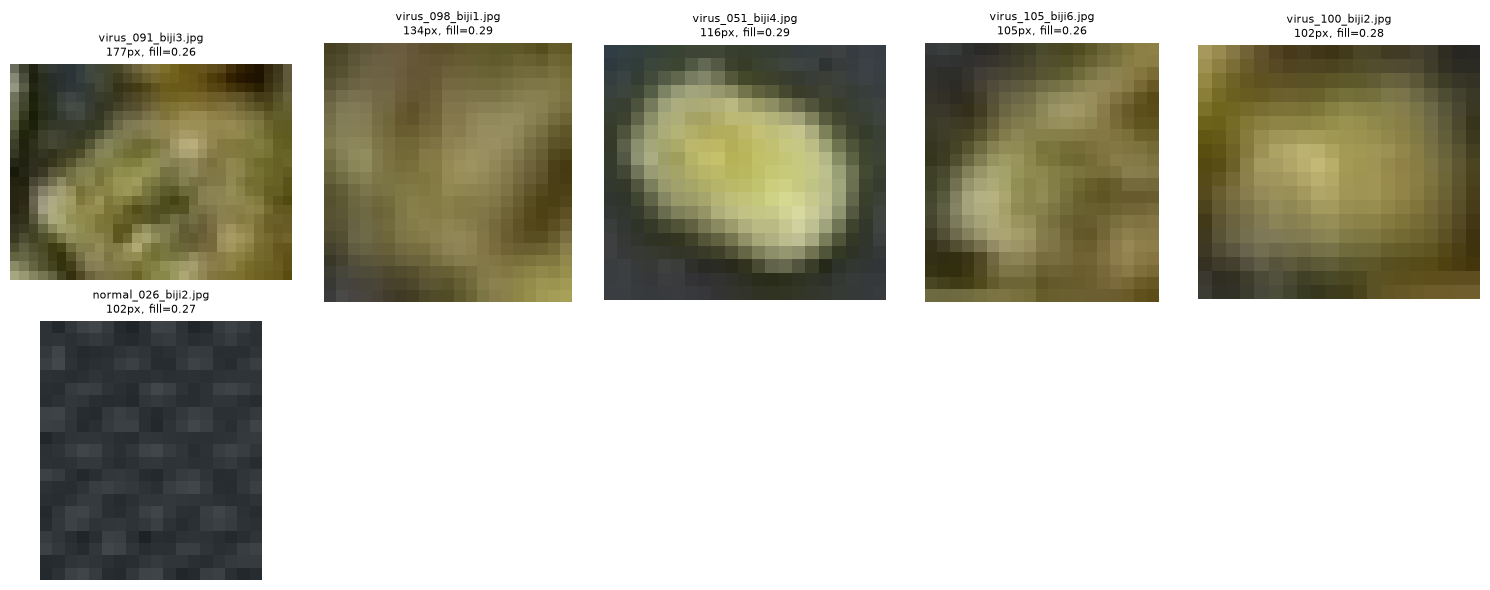

In [63]:
import matplotlib.pyplot as plt
import cv2, os

# daftar filename yang belum diverifikasi (area di bawah 400px dari kandidat_noise)
perlu_dicek = kandidat_noise[kandidat_noise["area_piksel"] < 400]

n = len(perlu_dicek)
cols = 5
rows = (n // cols) + 1
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

for i, (_, row) in enumerate(perlu_dicek.iterrows()):
    folder = "../data/cropped/sehat" if row["label"] == "sehat" else "../data/cropped/terkontaminasi"
    img = cv2.imread(os.path.join(folder, row["filename"]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{row['filename']}\n{row['area_piksel']:.0f}px, fill={row['fill_ratio']:.2f}", fontsize=8)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [64]:
import os
import pandas as pd

# baca manifest yang masih ada noise-nya
df_manifest = pd.read_csv("../data/manifest_crop.csv")

# daftar file yang sudah kita konfirmasi sebagai noise (bukan biji)
file_noise = [
    "virus_030_biji1.jpg",
    "virus_064_biji2.jpg",
    "virus_064_biji3.jpg",
    "virus_059_biji4.jpg",
    "virus_059_biji1.jpg",
    "normal_026_biji2.jpg",
]

# 1: hapus baris-baris ini dari manifest
jumlah_sebelum = len(df_manifest)
df_manifest = df_manifest[~df_manifest["filename"].isin(file_noise)]
jumlah_sesudah = len(df_manifest)
print(f"Baris manifest: {jumlah_sebelum} -> {jumlah_sesudah} (dihapus {jumlah_sebelum - jumlah_sesudah})")

# 2: hapus file fisiknya dari folder cropped
for nama_file in file_noise:
    # cari di folder mana filenya berada (sehat atau terkontaminasi)
    for folder in ["../data/cropped/sehat", "../data/cropped/terkontaminasi"]:
        path = os.path.join(folder, nama_file)
        if os.path.exists(path):
            os.remove(path)
            print(f"Dihapus: {path}")

# 3: simpan ulang manifest yang sudah bersih
df_manifest.to_csv("../data/manifest_crop.csv", index=False)
print(f"\nTotal crop final: {len(df_manifest)}")
print(df_manifest["label"].value_counts())

Baris manifest: 238 -> 237 (dihapus 1)
Dihapus: ../data/cropped/sehat\normal_026_biji2.jpg

Total crop final: 237
label
sehat             148
terkontaminasi     89
Name: count, dtype: int64


In [65]:
import pandas as pd

df_manifest = pd.read_csv("../data/manifest_crop.csv")
df_manifest["aspect_ratio"] = (
    df_manifest[["width", "height"]].max(axis=1) / df_manifest[["width", "height"]].min(axis=1)
)

kandidat_aneh = df_manifest[df_manifest["aspect_ratio"] > 2.0].sort_values("aspect_ratio", ascending=False)
print(f"Total crop sekarang: {len(df_manifest)}")
print(f"Jumlah crop dengan aspect_ratio > 2.0: {len(kandidat_aneh)}")
print(kandidat_aneh[["filename", "source_file", "label", "width", "height", "aspect_ratio", "area_piksel"]])

Total crop sekarang: 237
Jumlah crop dengan aspect_ratio > 2.0: 1
                 filename source_file  label  width  height  aspect_ratio  \
144  normal_079_biji1.jpg  normal_079  sehat     50      12      4.166667   

     area_piksel  
144        290.0  


normal_031: 0 crop
normal_079: 3 crop
normal_122: 0 crop
normal_123: 0 crop
normal_124: 0 crop
normal_125: 0 crop
normal_126: 0 crop
normal_127: 0 crop


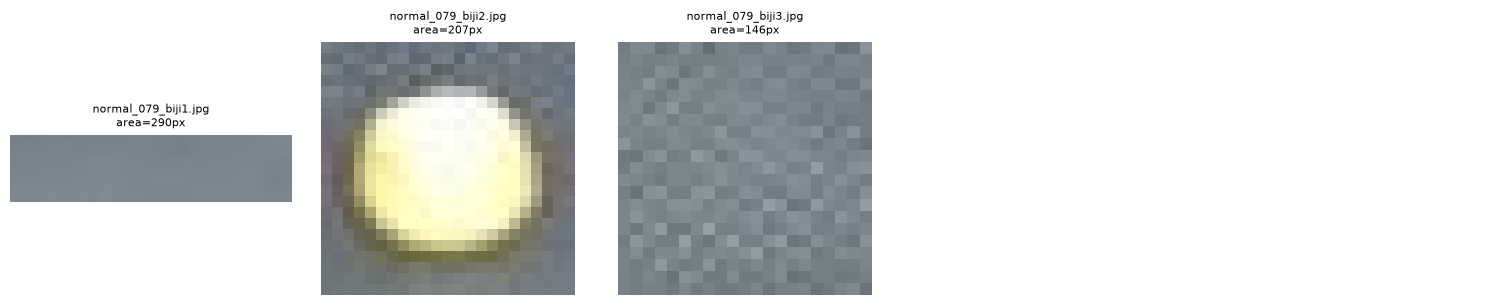

In [66]:
import matplotlib.pyplot as plt
import cv2, os
import pandas as pd

df_manifest = pd.read_csv("../data/manifest_crop.csv")

foto_dicurigai = ["normal_031", "normal_079", "normal_122", "normal_123", "normal_124", "normal_125", "normal_126", "normal_127"]

# cek dulu mana yang punya crop dan mana yang tidak
for nama in foto_dicurigai:
    jumlah = len(df_manifest[df_manifest["source_file"] == nama])
    print(f"{nama}: {jumlah} crop")

subset = df_manifest[df_manifest["source_file"].isin(foto_dicurigai)]

n = len(subset)
cols = 5
rows = (n // cols) + 1
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

for i, (_, row) in enumerate(subset.iterrows()):
    folder = f"../data/cropped/{row['label']}"
    img = cv2.imread(os.path.join(folder, row["filename"]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{row['filename']}\narea={row['area_piksel']:.0f}px", fontsize=8)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [67]:
import os
import pandas as pd

df_manifest = pd.read_csv("../data/manifest_crop.csv")

file_noise = [
    "normal_079_biji1.jpg",
    "normal_079_biji3.jpg",
    "normal_122_biji1.jpg",
    "normal_126_biji1.jpg",
    "normal_126_biji2.jpg",
]

jumlah_sebelum = len(df_manifest)
df_manifest = df_manifest[~df_manifest["filename"].isin(file_noise)]
print(f"Baris manifest: {jumlah_sebelum} -> {len(df_manifest)}")

for nama_file in file_noise:
    for folder in ["../data/cropped/sehat", "../data/cropped/terkontaminasi"]:
        path = os.path.join(folder, nama_file)
        if os.path.exists(path):
            os.remove(path)
            print(f"Dihapus: {path}")

df_manifest.to_csv("../data/manifest_crop.csv", index=False)
print(f"\nTotal crop final: {len(df_manifest)}")
print(df_manifest["label"].value_counts())

Baris manifest: 237 -> 235
Dihapus: ../data/cropped/sehat\normal_079_biji1.jpg
Dihapus: ../data/cropped/sehat\normal_079_biji3.jpg

Total crop final: 235
label
sehat             146
terkontaminasi     89
Name: count, dtype: int64
